 # MSIT675 Project 3
 In this project you will:
 1. Train and evaluate a bidirectional LSTM model for sentiment analysis using the [IMDB dataset](https://keras.io/api/datasets/imdb/).
 2. Finetune a [pretrained GPT-2 model](https://keras.io/keras_hub/api/models/gpt2/) using the IMDB dataset to generate positive reviews.
 3. Predict the probability reviews generated by your finetuned GPT-2 model are positive.

## Create Bidirectional LSTM Model [5 Points]

In the code cell below specify the code to create, compile and display the summary of a Bidirectional LSTM Model that meets the following criterion: The validation accuracy of your model must be over 0.85 with 20% of the training samples reserved for validation when trained on the keras IMDB dataset.

In [10]:
import numpy as np
import keras
from keras import layers
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt


# Define model hyperparameters
VOCAB_SIZE = 10000
MAX_LENGTH = 256
EMBED_DIM = 64
LSTM_DIM = 32

def get_data(vocab_size):
    (x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=vocab_size)
    WI = keras.datasets.imdb.get_word_index()
    REV_WI = dict([(value, key) for (key, value) in WI.items()])
    return (x_train, y_train), (x_test, y_test), WI, REV_WI

def to_wds(idx_list, REV_WI):
    return ' '.join([REV_WI.get(i-3, "") for i in idx_list[1:]])

def to_seq(text, WI, index_from=3, oov_char=2):
  """Returns sequence corresponding to text using WI"""
  W = [w.lower() for w in text.split() if w in WI]
  return [WI.get(w, oov_char) + index_from for w in W]

# Load the IMDB dataset
(x_train, y_train), (x_test, y_test), WI, REV_WI = get_data(VOCAB_SIZE)

# Print dataset statistics
print(f"Number of training samples: {len(y_train)} of which {sum(y_train)} are positive")
print(f"Number of test samples: {len(y_test)} of which {sum(y_test)} are positive")
# Print examples from training and test sets
print(f"First training sample labeled: {y_train[0]} is: {to_wds(x_train[0], REV_WI)}")
print(f"First test sample labeled: {y_test[0]} is: {to_wds(x_test[0], REV_WI)}")

def pad_sequences(x, maxlen=MAX_LENGTH):
    return keras.utils.pad_sequences(x, maxlen)

# Print shapes of padded input data
print(f"Shape of padded training inputs: {pad_sequences(x_train).shape}")
print(f"Shape of padded test inputs: {pad_sequences(x_test).shape}")

def Bidirectional_LSTM(VOCAB_SIZE, EMBED_DIM, LSTM_DIM):
    inputs = keras.Input(shape=(None,), dtype="int32")
    x = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(inputs)
    x = layers.Bidirectional(layers.LSTM(LSTM_DIM, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(LSTM_DIM))(x)
    # Add classifier
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    return model

model = Bidirectional_LSTM(VOCAB_SIZE, EMBED_DIM, LSTM_DIM)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Number of training samples: 25000 of which 12500 are positive
Number of test samples: 25000 of which 12500 are positive
First training sample labeled: 1 is: this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert  is an amazing actor and now the same being director  father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for  and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also  to the two little boy's that played the  of norman and paul they were just brilliant children are often left out of the  list i think because the stars that play t

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, None, 64)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, None, 64)       │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 689,729 (2.63 MB)

 Trainable params: 689,729 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

## Train model [5 Points]
In the code cell below specify the code to train your model.

In [11]:
# In this cell specify your code to train your model and run the cell
# so that the output confirms that validation accuracy is at least 0.85
batch_size=32
epochs=3
validation_split=0.2
model.fit(pad_sequences(x_train), y_train,
          batch_size=batch_size,
          epochs=epochs,
          validation_split=validation_split)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.7250 - loss: 0.5101 - val_accuracy: 0.8142 - val_loss: 0.5518
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9032 - loss: 0.2586 - val_accuracy: 0.8764 - val_loss: 0.3076
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.9454 - loss: 0.1534 - val_accuracy: 0.8672 - val_loss: 0.3623


## Evaluate trained model [5 Points]
In the code cell below specify your code to evaluate your trained model on the test samples. Display your classification report with metrics rounded to 4 decimal places and the Area Under the Receiver Operating Characteristic Curve.

In [12]:
# In this cell type in your code to evaluate your model on the test samples.
# Display the Area Under the Receiver Operating Characteristic Curve (rounded to 4 decimal places)
# Display your classification report with metrics rounded to 4 decimal places.

# Predict probabilities
pred = model.predict(pad_sequences(x_test))
print(f'roc_auc_score = {roc_auc_score(y_test, pred):0.4f}')
print("Classification report:")
print(classification_report(y_test, np.round(pred), digits=4))


782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step
roc_auc_score = 0.9376
Classification report:
              precision    recall  f1-score   support

           0     0.9034    0.8140    0.8564     12500
           1     0.8307    0.9130    0.8699     12500

    accuracy                         0.8635     25000
   macro avg     0.8671    0.8635    0.8631     25000
weighted avg     0.8671    0.8635    0.8631     25000



## Finetune GPT_2 on positive reviews [5 Points]
In the code cell below type in the code to finetune the GPT-2 model on *positive* [movie reviews](https://keras.io/api/datasets/imdb/)

In [13]:
# In this cell type in your code to finetune the GPT-2 model on positive reviews
# Call your model review_generator

# Concatenate training and test data to create a larger dataset for fine-tuning
x = np.concatenate([x_train, x_test])
y = np.concatenate([y_train, y_test])
x_pos = x[y==1]

# Convert the positive review indices back to readable text
positive_comments = [to_wds(c, REV_WI) for c in x_pos]
# Print a random sample comment to verify data quality
print(f'Sample comment:\n{positive_comments[np.random.randint(0, len(positive_comments))]}\n')

import os
import tensorflow as tf

os.environ["KERAS_BACKEND"] = "jax"

import keras_hub

# Enable mixed precision training to:
# 1. Speed up computation
# 2. Reduce memory usage
# 3. Allow for larger batch sizes
keras.mixed_precision.set_global_policy("mixed_float16")

# Use the same sequence length defined earlier for consistency
SEQUENCE_LENGTH = MAX_LENGTH

# Create a GPT-2 preprocessor from the preset
# This handles tokenization and input formatting for the model
preprocessor = keras_hub.models.GPT2CausalLMPreprocessor.from_preset(
    "gpt2_base_en",
    sequence_length=SEQUENCE_LENGTH,)

# Load the GPT-2 causal language model with the preprocessor attached
# This creates a review_generator model that will need fine-tuning
review_generator = keras_hub.models.GPT2CausalLM.from_preset("gpt2_base_en",
                                                             preprocessor=preprocessor)

print(f'\nFinetuning GPT-2 on {len(positive_comments)} positive comment.')

train_ds = (
    tf.data.Dataset.from_tensor_slices(positive_comments)
    .batch(16)
    .cache()
    .prefetch(tf.data.AUTOTUNE))

train_ds = train_ds.take(500)

num_epochs = 10

# Create a learning rate schedule that decays from 5e-5 to 0
# This helps stabilize training and prevent overfitting
learning_rate = keras.optimizers.schedules.PolynomialDecay(
    5e-5,
    decay_steps=train_ds.cardinality() * num_epochs,
    end_learning_rate=0.0,)

loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

review_generator.compile(
    optimizer=keras.optimizers.Adam(learning_rate),
    loss=loss,
    weighted_metrics=["accuracy"],
)

review_generator.fit(train_ds, epochs=num_epochs)

Sample comment:
i don't see what the problem is with some people and their need for intellectual humor you need to get your head out of your up tight ass if you don't find this movie hilarious if this isn't your cup of tea so to speak then look at it for what it truly is a damn funny movie maybe they did set out to make yet another drugs t a movie but in this case they've truly hit the spot it's especially funny for the ali g fans because he delivers everything we've come to love and expect from him so i say big ups to ali g and if it's not your thing don't   boy


Finetuning GPT-2 on 25000 positive comment.
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 340s 529ms/step - accuracy: 0.2656 - loss: 3.0090
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 265s 528ms/step - accuracy: 0.2932 - loss: 2.7915
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 265s 528ms/step - accuracy: 0.3035 - loss: 2.7173
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 265s 528ms/step - accuracy: 0.3116 - loss: 2.6623
Epoch 5/10
500/500 ━━━━━

## Generate fake reviews [5 Points]
In the code cell below type in the code to generate a list of 100 fake reviews generated by your *review_generator* and display the last 10 fake reviews.

In [24]:
# In this code cell type in the code to generate a list of 100 fake reviews
# generated by your review_generator and display the last 10 fake reviews.
k = 100
prompt = "In my opinion"
generated_comments = [review_generator.generate(prompt, max_length=MAX_LENGTH) for _ in range(k)]
print(f'{len(generated_comments)} comments generated')
print(f'Last 10 generated comments:')
for i,c in enumerate(generated_comments[-10:]):
    print(f'{i+91}. {c}')

100 comments generated
Last 10 generated comments:
91. In my opinion this is the best animated film ever made and the most  of all time i am not a big fan of the animation style but this film was very entertaining it was also very entertaining to watch the  of       and   are all very cute and the story itself was very interesting the animation was very good and the story line was very interesting and interesting the story itself is very interesting and interesting it is very interesting to watch the           and          the  and      were also very good and very interesting the story was very well told the animation is very good and the animation is very well drawn and drawn the story line was very well told it was also very well drawn the characters were very cute the story was also well drawn and the story line was very  the                             the                                              
92. In my opinion this is a very good film it has great actors and a good script

## Predict probability that fake reviews are positive [5 Points]
In the code cell below, predict the probability that each of the 100 fake reviews generated are positive. Display the mean and standard distribution of the probabilities and plot a histogram of the probabilities.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
generated comment scores: mean =  0.9668, std_dev = 0.1385


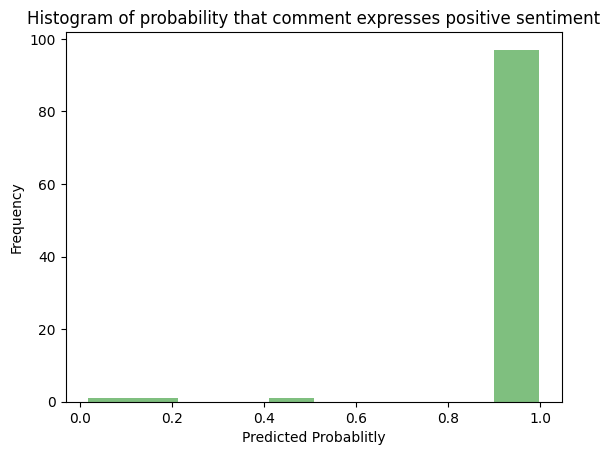

In [25]:
# In this code cell predict the probability that each of the 100 fake reviews generated are positive.
# Display the mean and standard distribution of the probabilities
# Plot a histogram of the probabilities.
generated_sequences = [to_seq(c.lower(), WI) for c in generated_comments]
pred_generated = model.predict(pad_sequences(generated_sequences))

print(f'generated comment scores: mean =  {np.mean(pred_generated):0.4f}, std_dev = {np.std(pred_generated):0.4f}')

plt.hist(pred_generated, color='green', alpha=0.5)

plt.xlabel('Predicted Probablitly')
plt.ylabel('Frequency')
plt.title('Histogram of probability that comment expresses positive sentiment')
plt.show()
